Saving FW_lagoon - food web by sampling.csv to FW_lagoon - food web by sampling (1).csv
Saving FW_lagoon - trophic links.csv to FW_lagoon - trophic links (1).csv
Saving FW_lagoon - nodes.csv to FW_lagoon - nodes (1).csv


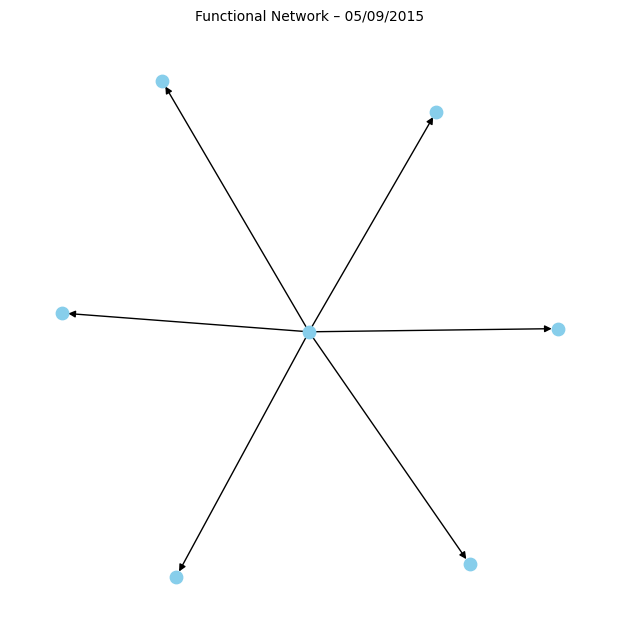

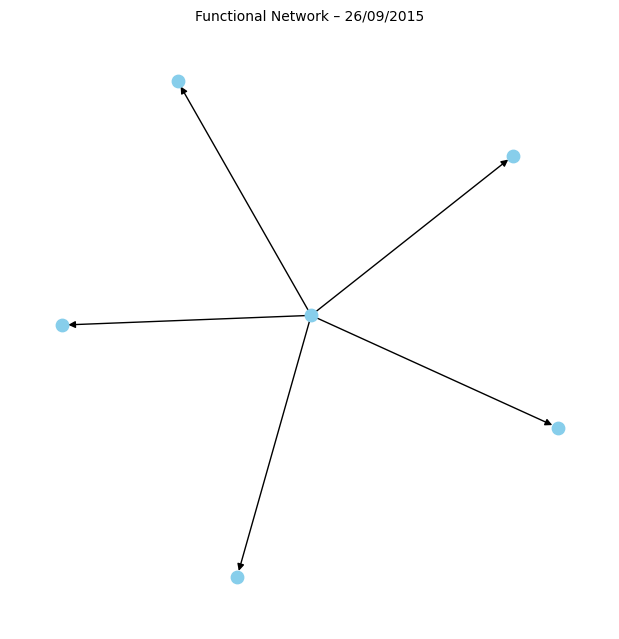

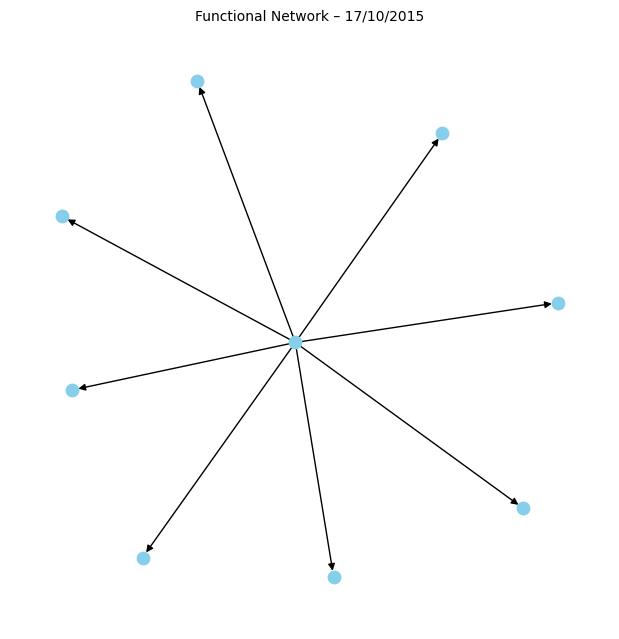

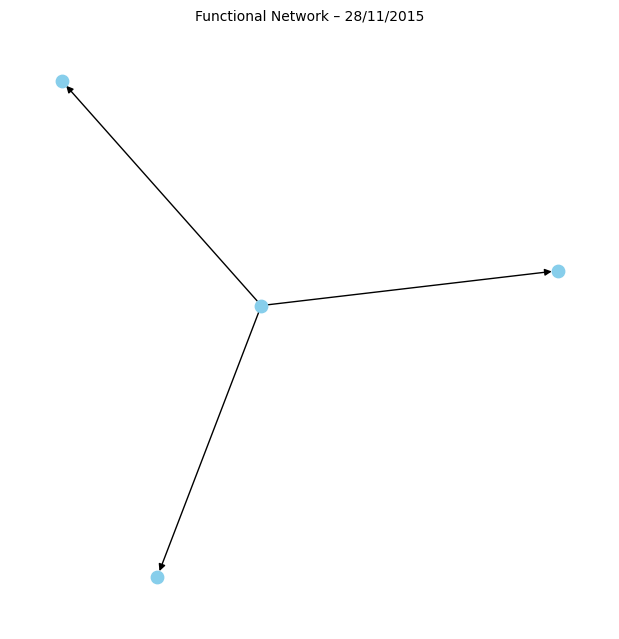

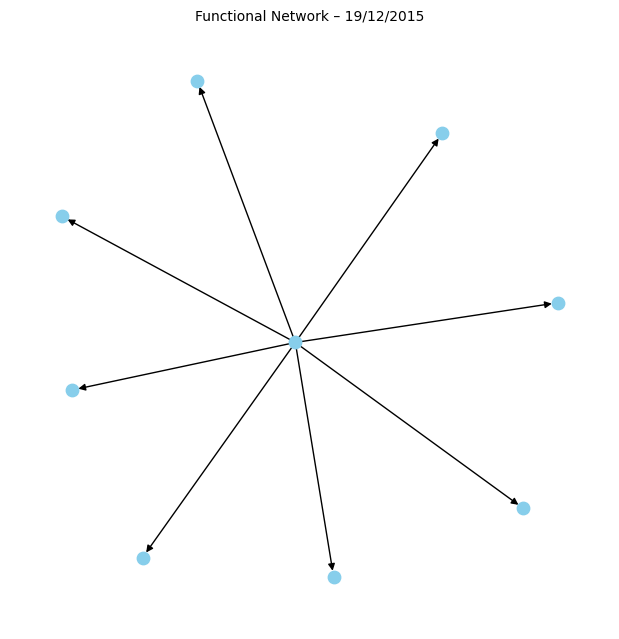

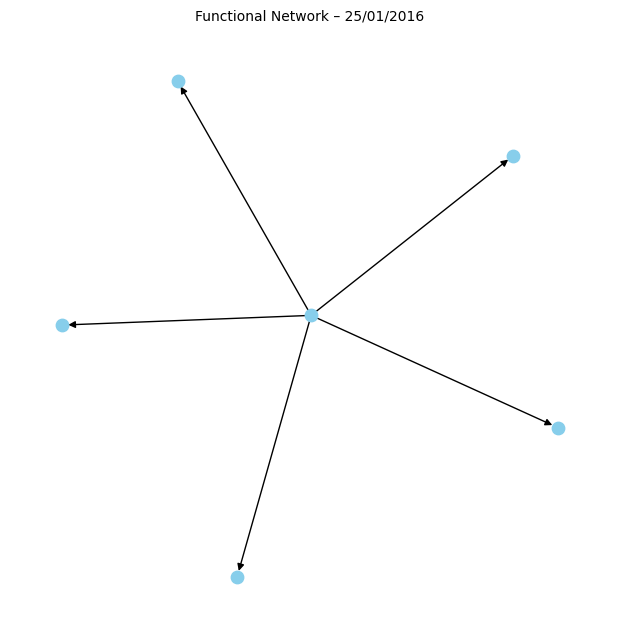

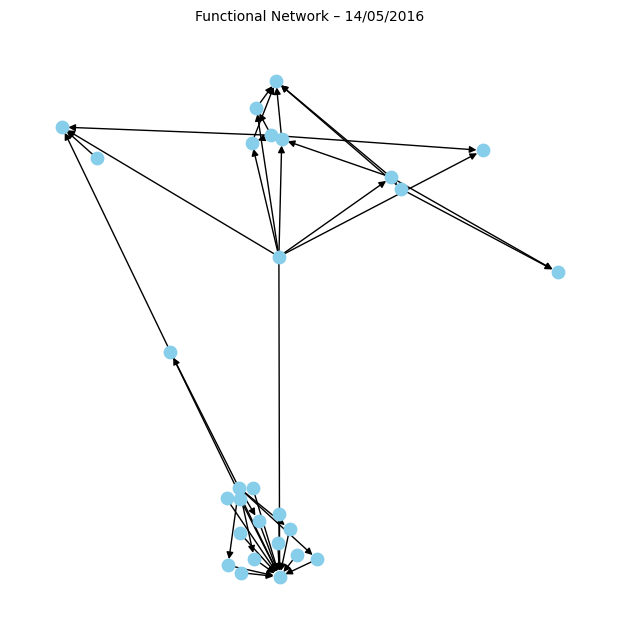

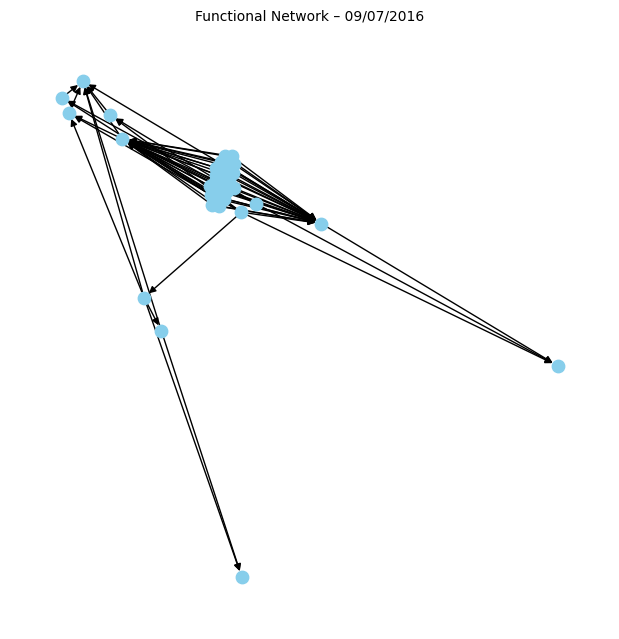

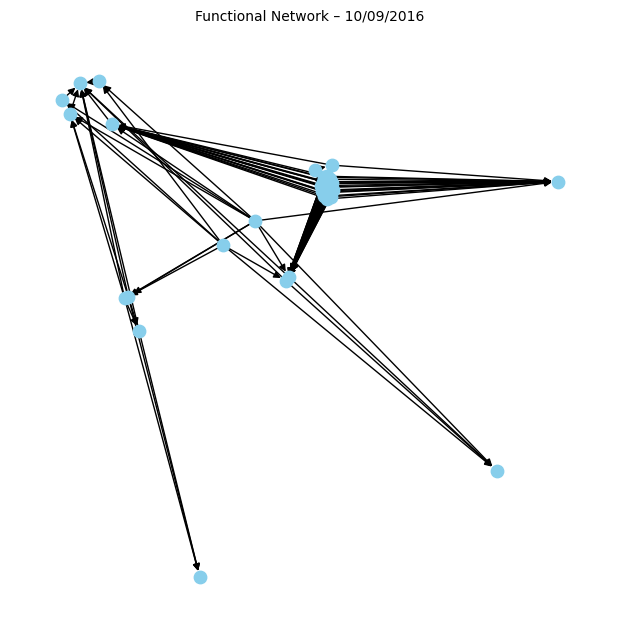

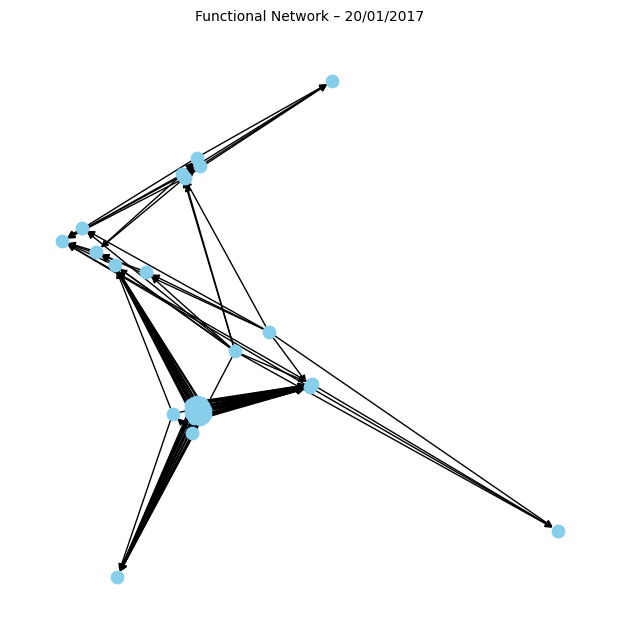

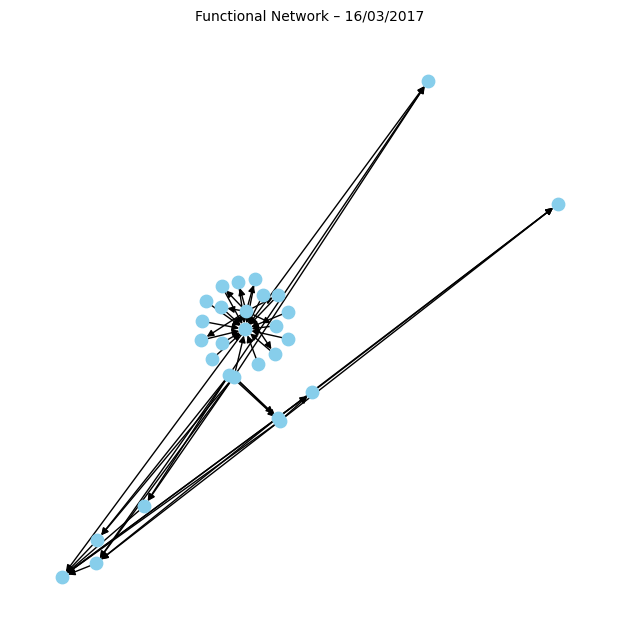

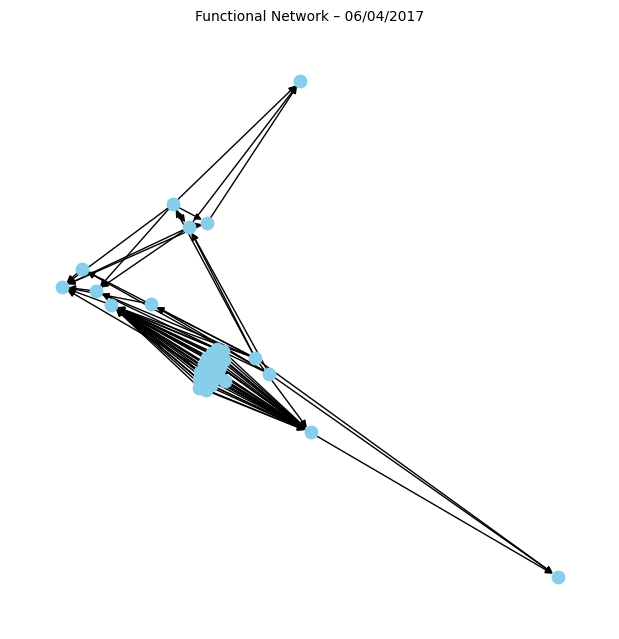

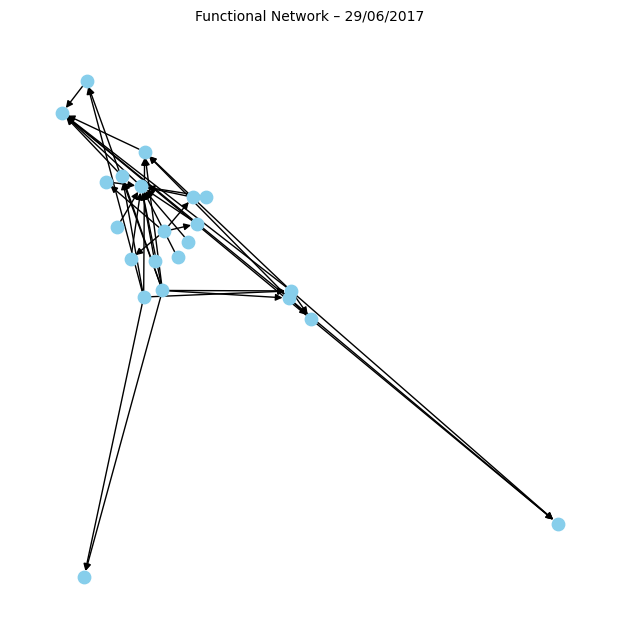

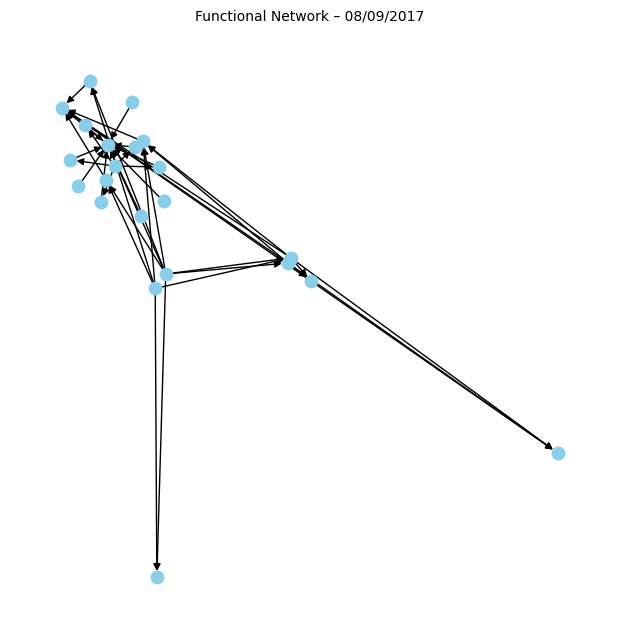

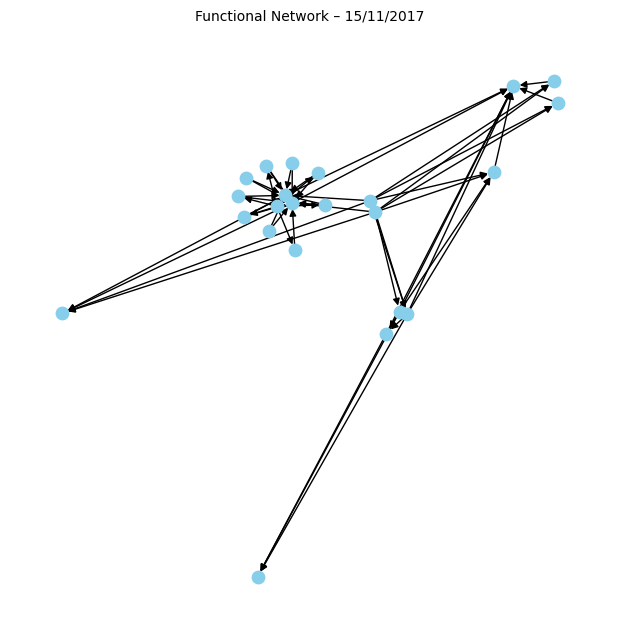

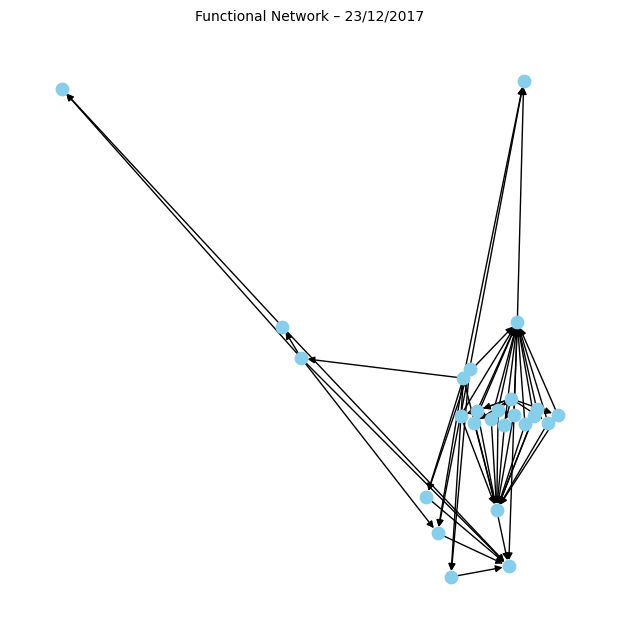

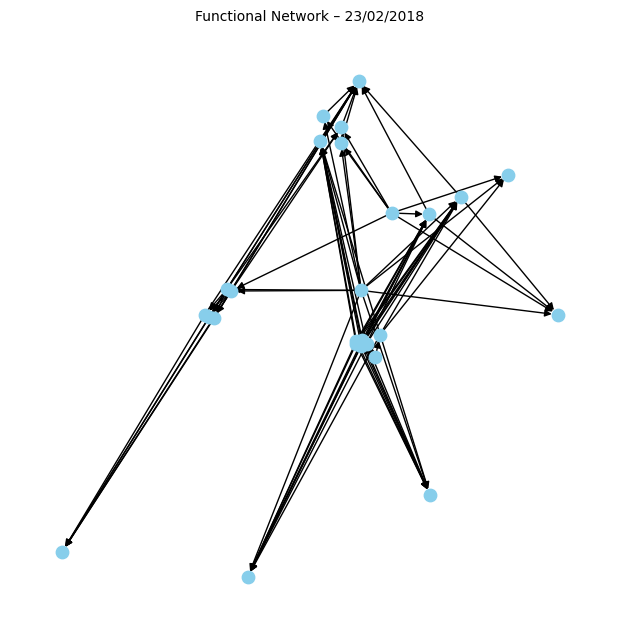

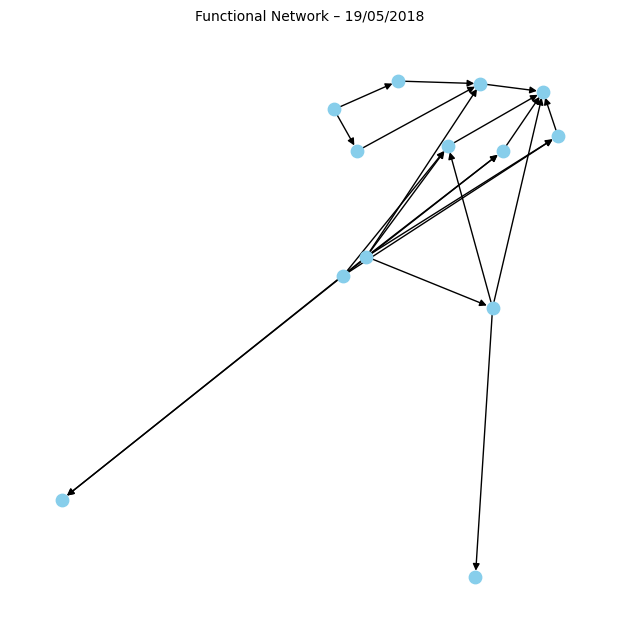

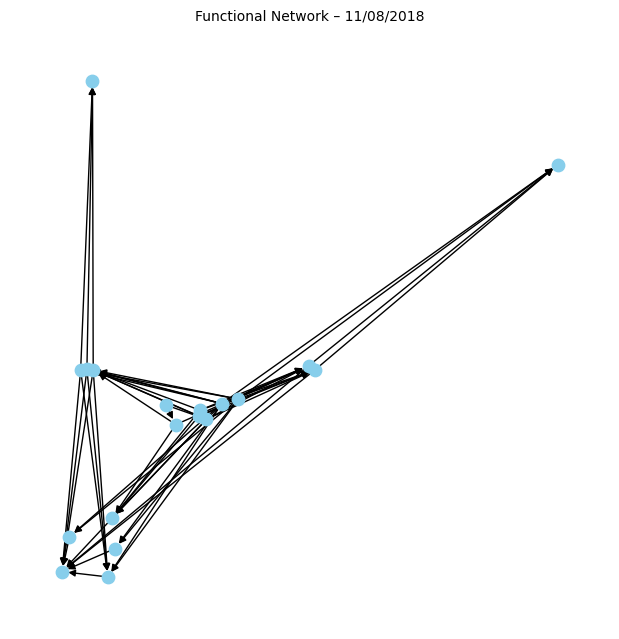

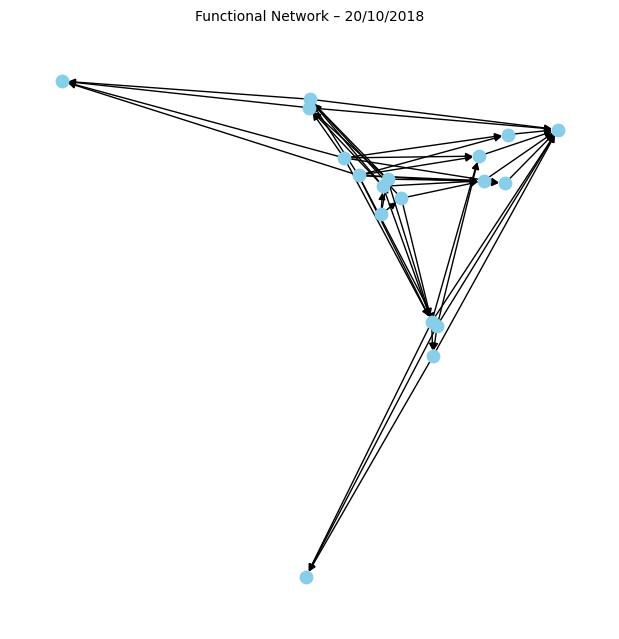

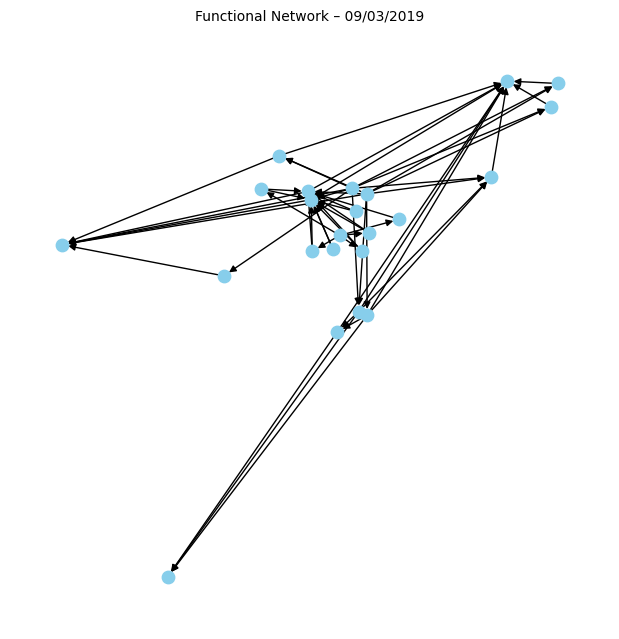

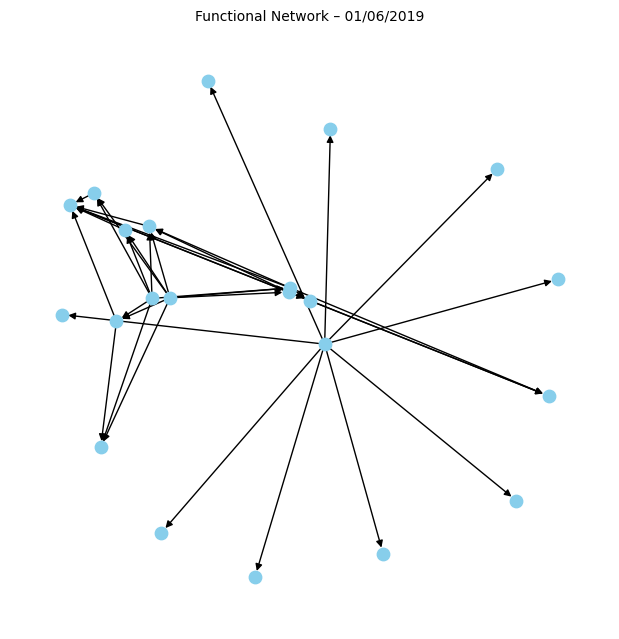

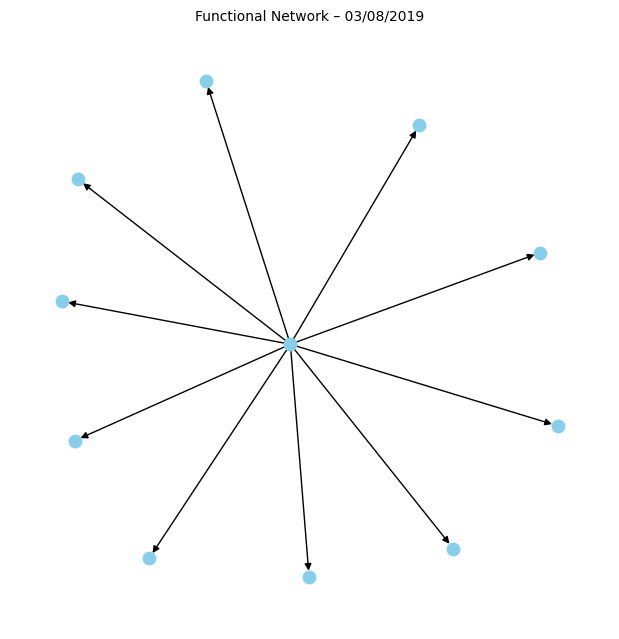

,date,nodes,links,connectance,average_links,average_level_trophic,maximum_trophic_level,modularity,centrality,betweenness
0,05/09/2015,7,6,0.142857,1.714286,1.857143,2,NaN,0.285714,0.000000
1,26/09/2015,6,5,0.166667,1.666667,1.833333,2,NaN,0.333333,0.000000
2,17/10/2015,9,8,0.111111,1.777778,1.888889,2,NaN,0.222222,0.000000
3,28/11/2015,4,3,0.250000,1.500000,1.750000,2,NaN,0.500000,0.000000
4,19/12/2015,9,8,0.111111,1.777778,1.888889,2,NaN,0.222222,0.000000
5,25/01/2016,6,5,0.166667,1.666667,1.833333,2,NaN,0.333333,0.000000
6,14/05/2016,28,44,0.058201,3.142857,1.785714,3,NaN,0.116402,0.000305
7,09/07/2016,33,77,0.072917,4.666667,1.969697,4,NaN,0.145833,0.001527
8,10/09/2016,33,112,0.106061,6.787879,2.030303,4,NaN,0.212121,0.001466
9,20/01/2017,37,127,0.095345,6.864865,1.945946,4,NaN,0.190691,0.001201


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ⬇️ Install library
!pip install networkx matplotlib pandas numpy --quiet

# 📚 Import libraries
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

# 📁 Add files
from google.colab import files
uploaded = files.upload()

# 🧾 files
df_nodes = pd.read_csv("FW_lagoon - nodes.csv")
df_links = pd.read_csv("FW_lagoon - trophic links.csv")
df_taxa = pd.read_csv("FW_lagoon - food web by sampling.csv", header=None)

# 🧹 Clean and format the taxa-by-date file header
dates = df_taxa.iloc[0].tolist()
df_taxa_clean = df_taxa.drop(0).reset_index(drop=True)
df_taxa_clean.columns = dates

# 🧾 Create a date-wise dictionary of present taxa
sampling_dict = {}
for col in df_taxa_clean.columns:
    taxa = df_taxa_clean[col].dropna().tolist()
    sampling_dict[col] = taxa

# 🧠  Build the functional network and compute metrics
def compute_functional_metrics(date, taxa_present, df_links, df_nodes):

    # Filter links where both endpoints are present on that day
    df_filtered = df_links[
        df_links["consumer"].isin(taxa_present) & df_links["resource"].isin(taxa_present)
    ]

    # CCreate a directed network
    G = nx.DiGraph()
    G.add_edges_from(zip(df_filtered["resource"], df_filtered["consumer"]))

    # Calculate metrics
    num_nodes = G.number_of_nodes()
    num_links = G.number_of_edges()
    connectance = num_links / (num_nodes * (num_nodes - 1)) if num_nodes > 1 else 0
    avg_degree = np.mean([d for n, d in G.degree()]) if num_nodes > 0 else 0

    #  Calculate trophic level using the shortest path method
    trophic_levels = {}
    try:
        for node in G.nodes():
            paths = nx.single_source_shortest_path_length(G.reverse(copy=False), node)
            levels = [l for n, l in paths.items() if G.in_degree(n) == 0]
            trophic_levels[node] = 1 + max(levels) if levels else 1
    except:
        trophic_levels = {n: 1 for n in G.nodes()}

    avg_trophic_level = np.mean(list(trophic_levels.values()))
    max_trophic_level = np.max(list(trophic_levels.values()))

    # Modularity by functional category (use column 'category' and 'taxon')
    if "category" in df_nodes.columns and "taxon" in df_nodes.columns:
        categories = dict(zip(df_nodes["taxon"], df_nodes["category"]))
        group_map = {n: categories.get(n, "unknown") for n in G.nodes()}
        communities = {}
        for n, g in group_map.items():
            communities.setdefault(g, set()).add(n)
        modularity = nx.algorithms.community.quality.modularity(G.to_undirected(), communities.values())
    else:
        modularity = np.nan
        group_map = {n: "gray" for n in G.nodes()}


    # Average centrality and betweenness
    centrality = np.mean(list(nx.degree_centrality(G).values()))
    betweenness = np.mean(list(nx.betweenness_centrality(G).values()))

       # Visualization
    plt.figure(figsize=(6, 6))
    pos = nx.spring_layout(G, seed=42)
    node_colors = [group_map[n] for n in G.nodes()]
    nx.draw(G, pos, with_labels=False, node_size=80, node_color=node_colors, arrows=True)
    plt.title(f"Functional Network – {date}", fontsize=10)
    plt.show()


    # Results
    return {
        "date": datetime.strptime(date, "%d/%m/%Y"),
        "nodes": num_nodes,
        "links": num_links,
        "connectance": connectance,
        "average_links": avg_degree,
        "average_level_trophic": avg_trophic_level,
        "maximum_trophic_level": max_trophic_level,
        "modularity": modularity,
        "centrality": centrality,
        "betweenness": betweenness,
    }

# 🚫 Filter dates for insufficient data (before 14th of May 2016)
dates_to_skip = [
    '30/05/2015', '04/07/2015', '15/07/2015', '11/09/2015',
    '03/10/2015', '27/11/2015', '15/01/2016', '12/02/2016', '15/03/2016'
]

# 🔁 Calculate by date
results = []
for date, taxa in sampling_dict.items():
    if date not in dates_to_skip:
        metrics = compute_functional_metrics(date, taxa, df_links, df_nodes)
        results.append(metrics)

# 📊 Create a table
df_results = pd.DataFrame(results)
df_results.sort_values(by="date", inplace=True)
df_results.reset_index(drop=True, inplace=True)
df_results["date"] = df_results["date"].dt.strftime("%d/%m/%Y")

# 🖨️ Show a table
import pandas as pd
from IPython.display import display
display(df_results)

# 💾 Download as csv file
df_results.to_csv("functional_network_metrics.csv", index=False)
files.download("functional_network_metrics.csv")